# /home/jovyan/millionsongsubset/

### biblioteke

In [94]:
import os
import h5py
import pandas as pd

BASE_DIR = './MillionSongSubset'

In [95]:
from implicit.als import AlternatingLeastSquares
import pickle

### Ucitavanje trening treningveci test i val seta i brisanje za model based

In [96]:
df_test = pd.read_csv('df_test2.csv')
df_val = pd.read_csv('df_val2.csv')
# df_train = pd.read_csv('df_train2.csv')
df_train = pd.read_csv('df_trainveci2.csv')

In [97]:
df_train_als = df_train.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
# df_train_als.sample(5)
# df_aa =pd.read_csv('df_train2.csv')
# df_aa.head()

In [98]:
df_test_als = df_test.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_test_als.sample(5)

,user_id,song_id,play_count,mode
7000,Always,SOSBXWX12A6701D235,1,1.0
18484,Kids Dance,SOFQBMN12A8C1428AD,1,0.0
32723,ThrowBack!!,SOYQNEQ12A6D4F7003,1,1.0
32186,The Collection,SOLFDCM12A6D4F7A7C,1,0.0
37860,black keys,SOMKGQN12A8C1339D2,1,1.0


### priprema za model based

In [99]:
# brisanje duplikata
df_als = df_train_als.groupby(['user_id', 'song_id'])['play_count'].sum().reset_index()


user_cat = df_als['user_id'].astype('category')
song_cat = df_als['song_id'].astype('category')

# mapiranje
user_map = {cat: i for i, cat in enumerate(user_cat.cat.categories)}
song_map = {cat: i for i, cat in enumerate(song_cat.cat.categories)}

df_als['user_id_idx'] = df_als['user_id'].map(user_map)
df_als['song_id_idx'] = df_als['song_id'].map(song_map)

# mapiranje na val i test a koristimo mapiranje od traina
df_test_als = df_test.copy()
df_test_als['user_id_idx'] = df_test_als['user_id'].map(user_map)
df_test_als['song_id_idx'] = df_test_als['song_id'].map(song_map)
df_test_als = df_test_als.dropna(subset=['user_id_idx', 'song_id_idx'])

df_val_als = df_val.copy()
df_val_als['user_id_idx'] = df_val_als['user_id'].map(user_map)
df_val_als['song_id_idx'] = df_val_als['song_id'].map(song_map)
df_val_als = df_val_als.dropna(subset=['user_id_idx', 'song_id_idx'])

# sparse matrica za als
from scipy.sparse import csr_matrix

sparse_item_user = csr_matrix(
    (df_als['play_count'], (df_als['song_id_idx'], df_als['user_id_idx']))
)

print("Podaci su spremni!")
print(f"Dimenzije matrice: {sparse_item_user.shape}")
print(f"Train interakcije: {len(df_als)}, Test: {len(df_test_als)}, Val: {len(df_val_als)}")

Podaci su spremni!
Dimenzije matrice: (2262, 26974)
Train interakcije: 124640, Test: 50251, Val: 36505


### model

In [ ]:
import os
import pickle
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import ranking_metrics_at_k

broj_faktora = 200
regularizacija = 25
K_ZA_EVALUACIJU = 10
br_epoha = 20  

ime_podfoldera = f'finalni_model_manji_f{broj_faktora}_reg{regularizacija}' 
putanja_foldera = os.path.join('sacuvani_modeli', ime_podfoldera)
if not os.path.exists(putanja_foldera):
    os.makedirs(putanja_foldera)

user_item_matrix = sparse_item_user.T.tocsr()

val_user_indices = df_val_als['user_id_idx'].astype(int).values
val_item_indices = df_val_als['song_id_idx'].astype(int).values
val_values = df_val_als.get('play_count', [1] * len(df_val_als))
val_matrix = csr_matrix(
    (val_values, (val_user_indices, val_item_indices)),
    shape=user_item_matrix.shape
)

svi_rezultati_epohe = []
najbolji_ndcg = -1
najbolja_epoha = -1

for epoha in range(1, br_epoha + 1):
    
    model = AlternatingLeastSquares(
        factors=broj_faktora,
        regularization=regularizacija,
        iterations=epoha,       
        random_state=42
    )
    model.fit(user_item_matrix, show_progress=False)

    ime_fajla = os.path.join(putanja_foldera, f'epoha_{epoha:02d}.pkl')
    with open(ime_fajla, 'wb') as f:
        pickle.dump(model, f)

    metrike = ranking_metrics_at_k(
        model,
        train_user_items=user_item_matrix,
        test_user_items=val_matrix,
        K=K_ZA_EVALUACIJU,
        show_progress=False
    )

    rezultat = {
        'epoha': epoha,
        'factors': broj_faktora,
        'regularization': regularizacija,
        'map': metrike['map'],
        'ndcg': metrike['ndcg'],
        'hit_rate': metrike['precision'], 
    }
    svi_rezultati_epohe.append(rezultat)

    print(f"Epoha {epoha:02d}: MAP@{K_ZA_EVALUACIJU}={metrike['map']:.4f} | "
          f"NDCG@{K_ZA_EVALUACIJU}={metrike['ndcg']:.4f} | "
          f"Implicit Prec (HR)@{K_ZA_EVALUACIJU}={metrike['precision']:.4f}")

    if metrike['ndcg'] > najbolji_ndcg:
        najbolji_ndcg = metrike['ndcg']
        najbolja_epoha = epoha

print(f"\n najbolja epoha gledajući samo čist NDCG: {najbolja_epoha}")

Ime_rezultata = f'rezultati_epohe_f{broj_faktora}_reg{regularizacija}.pkl'
with open(Ime_rezultata, 'wb') as f:
    pickle.dump(svi_rezultati_epohe, f)

df_rez = pd.DataFrame(svi_rezultati_epohe)

map_norm = (df_rez['map'] - df_rez['map'].min()) / (df_rez['map'].max() - df_rez['map'].min() + 1e-9)
ndcg_norm = (df_rez['ndcg'] - df_rez['ndcg'].min()) / (df_rez['ndcg'].max() - df_rez['ndcg'].min() + 1e-9)
hr_norm = (df_rez['hit_rate'] - df_rez['hit_rate'].min()) / (df_rez['hit_rate'].max() - df_rez['hit_rate'].min() + 1e-9)

w_hr = 0.53
w_map = 0.23
w_ndcg = 0.24
df_rez['izbalansirani_skor'] = (w_hr * hr_norm) + (w_map * map_norm) + (w_ndcg * ndcg_norm)

pobednik = df_rez.loc[df_rez['izbalansirani_skor'].idxmax()]

print(f"Najbolja epoha Epoha {int(pobednik['epoha'])}")
print(f"Rezultati koje ova epoha ostvaruje na validaciji:")
print(f"  Hit Rate@10: {pobednik['hit_rate']:.4f}")
print(f"  MAP@10:      {pobednik['map']:.4f}")
print(f"  NDCG@10:     {pobednik['ndcg']:.4f}")

Epoha 01: MAP@10=0.0589 | NDCG@10=0.0861 | Implicit Prec (HR)@10=0.1212
Epoha 02: MAP@10=0.1345 | NDCG@10=0.1885 | Implicit Prec (HR)@10=0.2543
Epoha 03: MAP@10=0.1498 | NDCG@10=0.2066 | Implicit Prec (HR)@10=0.2709
Epoha 04: MAP@10=0.1524 | NDCG@10=0.2096 | Implicit Prec (HR)@10=0.2748
Epoha 05: MAP@10=0.1539 | NDCG@10=0.2104 | Implicit Prec (HR)@10=0.2744
Epoha 06: MAP@10=0.1519 | NDCG@10=0.2073 | Implicit Prec (HR)@10=0.2707
Epoha 07: MAP@10=0.1497 | NDCG@10=0.2057 | Implicit Prec (HR)@10=0.2719
Epoha 08: MAP@10=0.1486 | NDCG@10=0.2049 | Implicit Prec (HR)@10=0.2723
Epoha 09: MAP@10=0.1483 | NDCG@10=0.2051 | Implicit Prec (HR)@10=0.2730
Epoha 10: MAP@10=0.1492 | NDCG@10=0.2058 | Implicit Prec (HR)@10=0.2729
Epoha 11: MAP@10=0.1504 | NDCG@10=0.2071 | Implicit Prec (HR)@10=0.2736
Epoha 12: MAP@10=0.1507 | NDCG@10=0.2076 | Implicit Prec (HR)@10=0.2744
Epoha 13: MAP@10=0.1510 | NDCG@10=0.2079 | Implicit Prec (HR)@10=0.2745
Epoha 14: MAP@10=0.1516 | NDCG@10=0.2084 | Implicit Prec (HR)@10

In [135]:
import numpy as np
als_predictions = np.dot(model.user_factors, model.item_factors.T)

print("Dimenzije ALS predikcija:", als_predictions.shape)
print(als_predictions)

Dimenzije ALS predikcija: (26974, 2262)
[[-1.2020381e-03 -3.8108660e-04 -1.0644618e-03 ... -5.9761645e-05
  -6.6027887e-06 -2.2630765e-04]
 [-2.3303143e-04  1.3486250e-05 -1.1728619e-03 ... -2.8982581e-04
   1.0024099e-04 -1.3981049e-04]
 [ 6.5162269e-05  1.8190492e-03  2.1331229e-04 ... -1.6503547e-04
  -6.2109371e-05  7.0652124e-05]
 ...
 [ 2.0932946e-04 -2.5333816e-04  5.9731881e-04 ...  1.0004418e-04
  -6.7668392e-05 -3.6607202e-05]
 [ 7.0614764e-04  2.0104710e-03  6.8016798e-04 ... -6.8525369e-05
  -2.0115220e-04 -4.7921445e-04]
 [ 4.9550512e-05  7.2376890e-05 -7.7840418e-04 ... -2.1710487e-04
   6.7556823e-05  2.1667569e-04]]


In [136]:
# normalizujemo predikcije als modela da bi mogli da ga kombinujemo sa cosin sim
min_po_redu = als_predictions.min(axis=1, keepdims=True)
max_po_redu = als_predictions.max(axis=1, keepdims=True)

als_predictions = (als_predictions - min_po_redu) / (max_po_redu - min_po_redu + 1e-7)

print("Dimenzije normalizovane ALS matrice:", als_predictions.shape)
print("Minimalna vrednost u matrici nakon normalizacije:", als_predictions.min())
print("Maksimalna vrednost u matrici nakon normalizacije:", als_predictions.max())
print(als_predictions)


Dimenzije normalizovane ALS matrice: (26974, 2262)
Minimalna vrednost u matrici nakon normalizacije: 0.0
Maksimalna vrednost u matrici nakon normalizacije: 0.99999994
[[0.00926593 0.01101081 0.00955834 ... 0.01169377 0.01180676 0.01133979]
 [0.06386804 0.06606865 0.05547838 ... 0.06336105 0.06684308 0.0647002 ]
 [0.15866302 0.20263794 0.16237757 ... 0.15289131 0.15547197 0.15880066]
 ...
 [0.01982206 0.01857506 0.02086779 ... 0.01952751 0.01907548 0.0191592 ]
 [0.04316802 0.04907421 0.04305039 ... 0.03966018 0.03905962 0.03780051]
 [0.02531736 0.02540353 0.02219174 ... 0.02431071 0.02538534 0.02594828]]


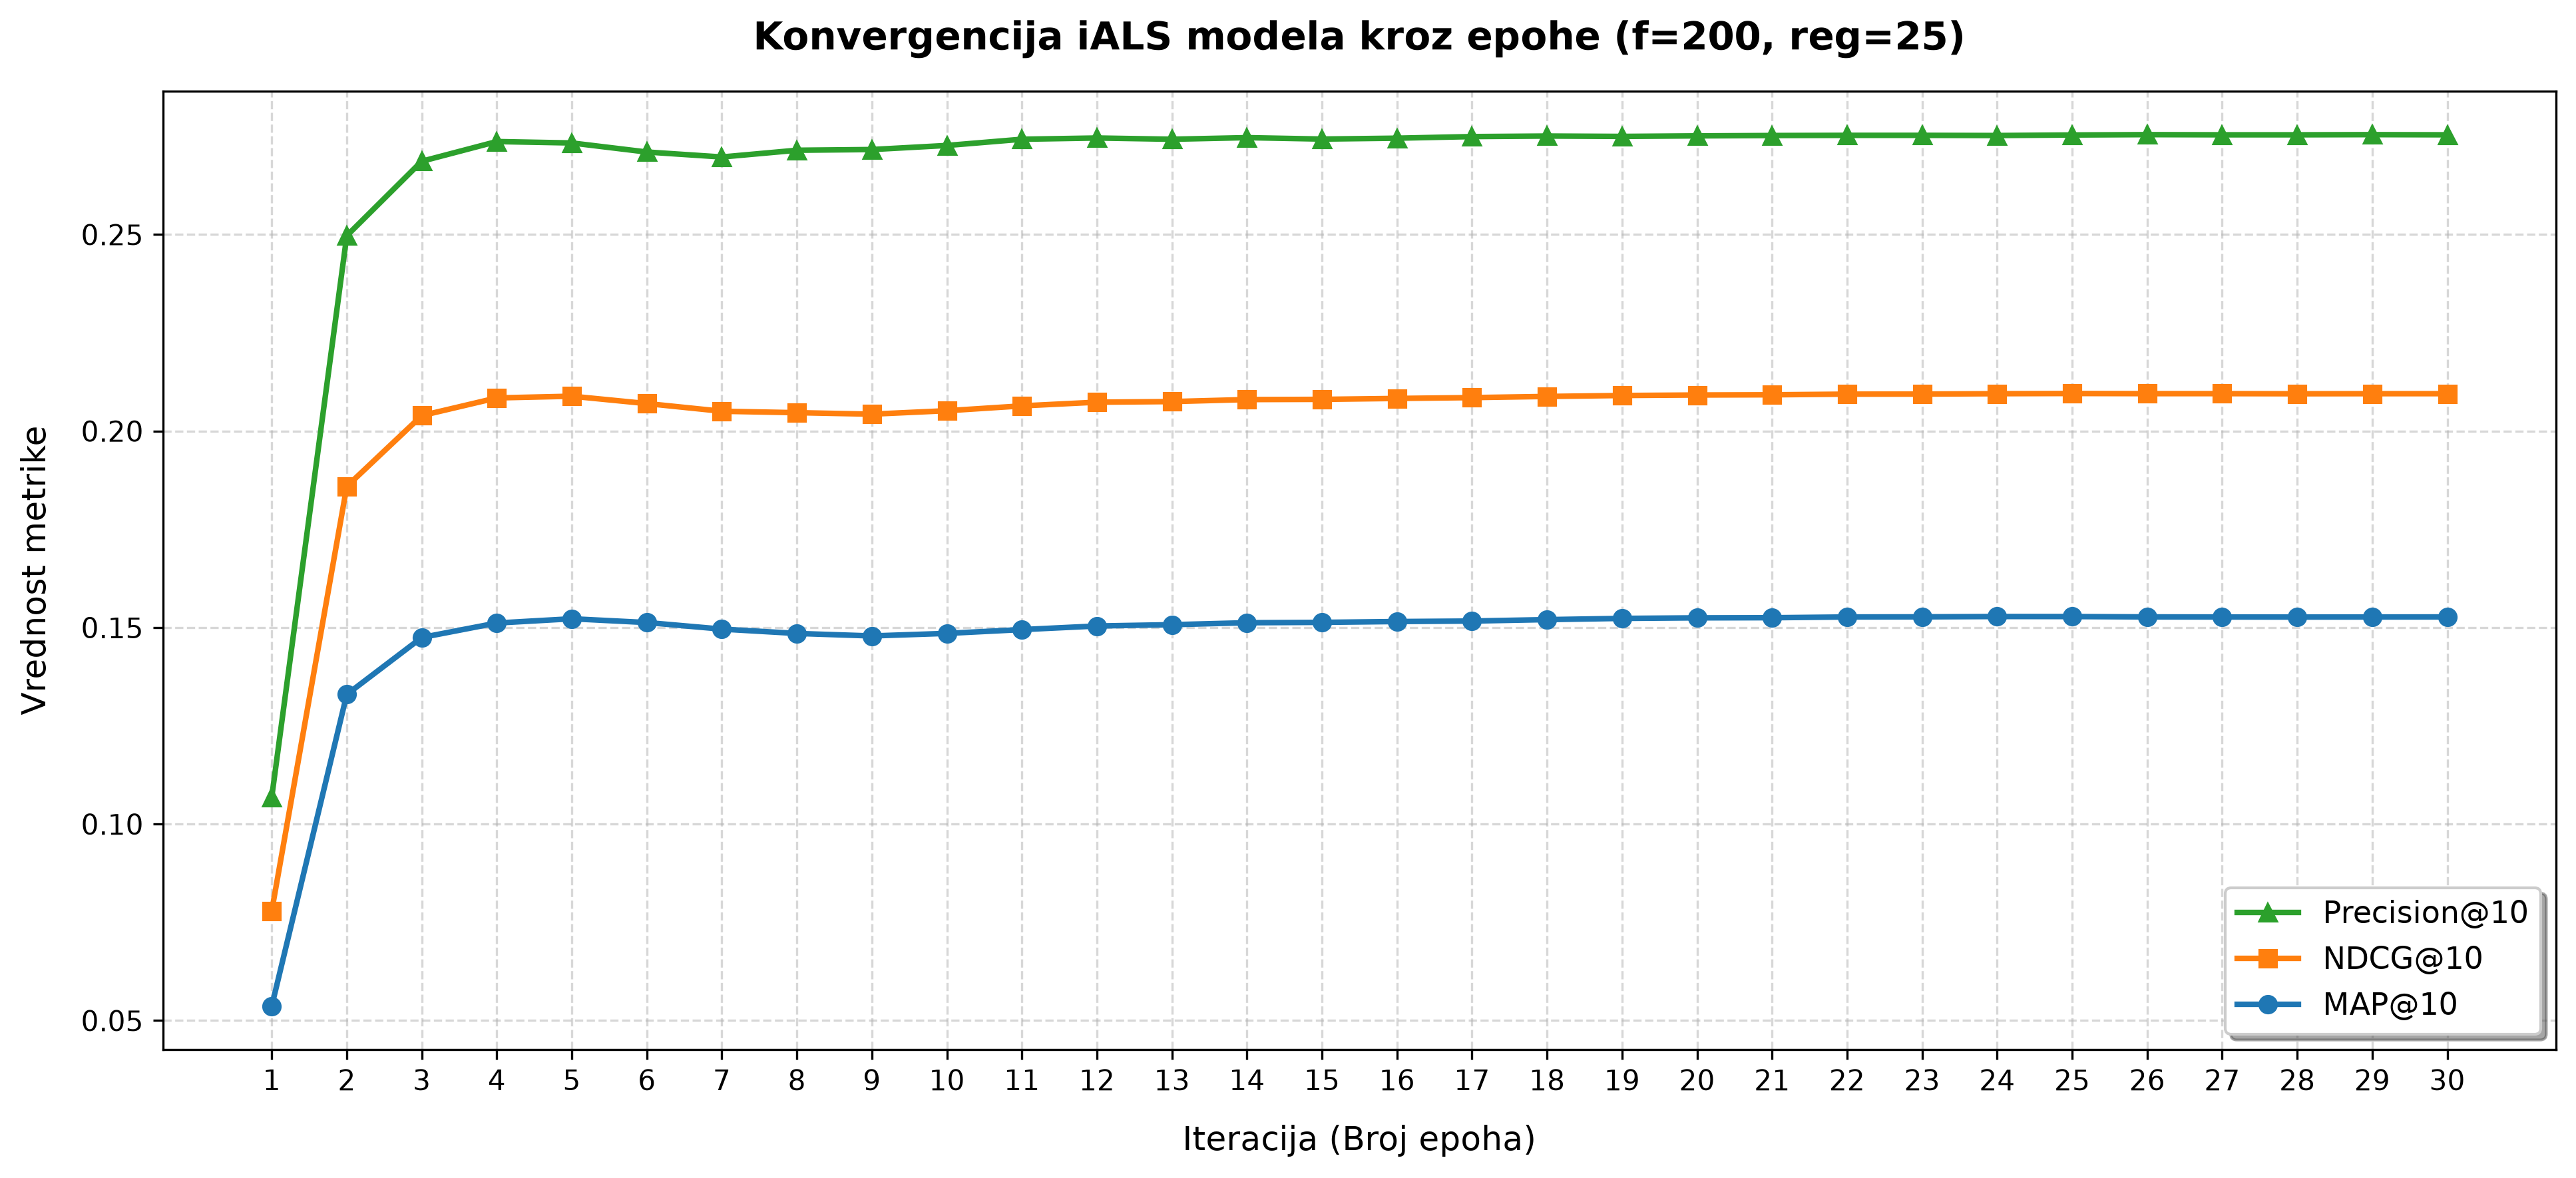

In [ ]:
import matplotlib.pyplot as plt

epohe = range(1, len(istorija_map) + 1)


plt.figure(figsize=(13, 6), dpi=300) 


plt.plot(epohe, istorija_preciznosti, marker='^', linestyle='-', linewidth=2, markersize=6, color='#2ca02c', label='Precision@10')
plt.plot(epohe, istorija_ndcg, marker='s', linestyle='-', linewidth=2, markersize=6, color='#ff7f0e', label='NDCG@10')
plt.plot(epohe, istorija_map, marker='o', linestyle='-', linewidth=2, markersize=6, color='#1f77b4', label='MAP@10')


plt.title('Konvergencija iALS modela kroz epohe (f=200, reg=25)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Iteracija (Broj epoha)', fontsize=12, labelpad=10)
plt.ylabel('Vrednost metrike', fontsize=12, labelpad=10)
plt.xticks(epohe, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)

# Prefinjena isprekidana mreža u pozadini
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('konvergencija_modela_izduzeno.png', dpi=300, bbox_inches='tight')

plt.show()

In [138]:
# ucitavanje modela

putanja_do_modela = r'/home/jovyan/millionsongsubset/sacuvani_modeli/finalni_model_manji_f200_reg25/epoha_05.pkl'

#RAHH

with open(putanja_do_modela, 'rb') as f:
    model = pickle.load(f)

print(f"model {putanja_do_modela} je ucitan")

model /home/jovyan/millionsongsubset/sacuvani_modeli/finalni_model_manji_f200_reg25/epoha_05.pkl je ucitan


In [ ]:
import os
import pickle
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.evaluation import ranking_metrics_at_k


K_ZA_EVALUACIJU = 10


# Trening matrica
user_item_matrix = sparse_item_user.T.tocsr()

# priprema
test_user_indices = df_test_als['user_id_idx'].astype(int).values
test_item_indices = df_test_als['song_id_idx'].astype(int).values
test_values = df_test_als.get('play_count', [1] * len(df_test_als))

test_matrix = csr_matrix(
    (test_values, (test_user_indices, test_item_indices)), 
    shape=user_item_matrix.shape
)

# evaluacija
print("Pokrećem finalnu evaluaciju na test skupu...")
metrike = ranking_metrics_at_k(
    model, 
    train_user_items=user_item_matrix, 
    test_user_items=test_matrix, 
    K=K_ZA_EVALUACIJU,
    show_progress=True
)


metrics_df = pd.DataFrame({
    'Metrika': [f'Precision@{K_ZA_EVALUACIJU}', f'MAP@{K_ZA_EVALUACIJU}', f'NDCG@{K_ZA_EVALUACIJU}'],
    'Vrednost': [metrike['precision'], metrike['map'], metrike['ndcg']]
})

print("\nrezultati na test setu")
print(metrics_df.to_string(index=False))

Pokrećem finalnu evaluaciju na test skupu...


  0%|          | 0/21792 [00:00<?, ?it/s]


--- Finalni rezultati na test setu ---
     Metrika  Vrednost
Precision@10  0.300364
      MAP@10  0.169069
     NDCG@10  0.221767


In [ ]:
import os
import pickle
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.evaluation import ranking_metrics_at_k

# parametri
broj_faktora = 200
regularizacija = 25  # 30 mejbi isto
K_ZA_EVALUACIJU = 10

ime_podfoldera = '/home/jovyan/millionsongsubset/sacuvani_modeli/finalni_model_manji_f200_reg25' 
putanja_foldera = os.path.join('sacuvani_modeli', ime_podfoldera)

# matrica za tr 
user_item_matrix = sparse_item_user.T.tocsr()

# priprema test seta
test_user_indices = df_test_als['user_id_idx'].astype(int).values
test_item_indices = df_test_als['song_id_idx'].astype(int).values
test_values = df_test_als.get('play_count', [1] * len(df_test_als))

test_matrix = csr_matrix(
    (test_values, (test_user_indices, test_item_indices)), 
    shape=user_item_matrix.shape
)


najbolji_ndcg = -1.0
najbolja_epoha = -1
najbolje_metrike = {}

print(f"Pokrećem evaluaciju test skupa kroz svih 20 epoha za: {ime_podfoldera}\n")

# petlja kroz epohe
for i in range(1, 21):
    ime_fajla = os.path.join(putanja_foldera, f'epoha_{i:02d}.pkl')
    
    # pr da li postoji fajl
    if not os.path.exists(ime_fajla):
        print(f"Fajl {ime_fajla} ne postoji, preskačem...")
        continue
        
    # ucitavanje modela za trenutnu epohu
    with open(ime_fajla, 'rb') as f:
        model = pickle.load(f)
        
    # evaluacija
    metrike = ranking_metrics_at_k(
        model, 
        train_user_items=user_item_matrix, 
        test_user_items=test_matrix, 
        K=K_ZA_EVALUACIJU,
        show_progress=False
    )
    
    trenutni_prec = metrike['precision']
    trenutni_map = metrike['map']
    trenutni_ndcg = metrike['ndcg']
    
    print(f"Epoha {i:02d}: Precision@{K_ZA_EVALUACIJU} = {trenutni_prec:.4f} | MAP@{K_ZA_EVALUACIJU} = {trenutni_map:.4f} | NDCG@{K_ZA_EVALUACIJU} = {trenutni_ndcg:.4f}")
    
    # Logika za pronalaženje najboljeg modela (na osnovu NDCG@10)
    if trenutni_ndcg > najbolji_ndcg:
        najbolji_ndcg = trenutni_ndcg
        najbolja_epoha = i
        najbolje_metrike = metrike

# 4. ISPIS NAJBOLJIH REZULTATA NA KRAJU
print(f"  NAJBOLJI REZULTATI NA TEST SETU OSTVARENI U EPOHI: {najbolja_epoha}")
final_metrics_df = pd.DataFrame({
    'Metrika': [f'Hit Rate@{K_ZA_EVALUACIJU}', f'MAP@{K_ZA_EVALUACIJU}', f'NDCG@{K_ZA_EVALUACIJU}'],
    'Vrednost': [najbolje_metrike['precision'], najbolje_metrike['map'], najbolje_metrike['ndcg']]
})

print(final_metrics_df.to_string(index=False))

Pokrećem evaluaciju test skupa kroz svih 20 epoha za: /home/jovyan/millionsongsubset/sacuvani_modeli/finalni_model_manji_f200_reg25

Epoha 01: Precision@10 = 0.1451 | MAP@10 = 0.0707 | NDCG@10 = 0.0994
Epoha 02: Precision@10 = 0.2812 | MAP@10 = 0.1464 | NDCG@10 = 0.1986
Epoha 03: Precision@10 = 0.3040 | MAP@10 = 0.1668 | NDCG@10 = 0.2217
Epoha 04: Precision@10 = 0.3033 | MAP@10 = 0.1690 | NDCG@10 = 0.2228
Epoha 05: Precision@10 = 0.3004 | MAP@10 = 0.1691 | NDCG@10 = 0.2218
Epoha 06: Precision@10 = 0.2951 | MAP@10 = 0.1654 | NDCG@10 = 0.2172
Epoha 07: Precision@10 = 0.2947 | MAP@10 = 0.1621 | NDCG@10 = 0.2143
Epoha 08: Precision@10 = 0.2955 | MAP@10 = 0.1598 | NDCG@10 = 0.2127
Epoha 09: Precision@10 = 0.2966 | MAP@10 = 0.1589 | NDCG@10 = 0.2123
Epoha 10: Precision@10 = 0.2976 | MAP@10 = 0.1592 | NDCG@10 = 0.2130
Epoha 11: Precision@10 = 0.2984 | MAP@10 = 0.1597 | NDCG@10 = 0.2137
Epoha 12: Precision@10 = 0.2993 | MAP@10 = 0.1604 | NDCG@10 = 0.2144
Epoha 13: Precision@10 = 0.3001 | MAP@1

### cosin

In [143]:
df_test = pd.read_csv('df_test2.csv')
df_val = pd.read_csv('df_val2.csv')
# df_train = pd.read_csv('df_train2.csv')
df_train = pd.read_csv('df_trainveci2.csv')
df_finalni = pd.read_csv('mergeovan.csv')

In [144]:
import ast

def pripremi_terms(terms_list):
    if isinstance(terms_list, str):
        try:
            terms_list = ast.literal_eval(terms_list)
        except (ValueError, SyntaxError):
            return "" 
            
    if not isinstance(terms_list, list) or len(terms_list) == 0: 
        return ""
        
    return " ".join([term.replace(" ", "_") for term in terms_list])

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

if not df_train.empty and not df_test.empty:
    
   
    def pripremi_terms(terms_list):
        if isinstance(terms_list, str):
            try:
                terms_list = ast.literal_eval(terms_list)
            except (ValueError, SyntaxError):
                return "" 
                
        if not isinstance(terms_list, list) or len(terms_list) == 0: 
            return ""
            
        return " ".join([term.replace(" ", "_") for term in terms_list])
    df_train['terms_clean_text'] = df_train['artist_terms'].apply(pripremi_terms)
    df_test['terms_clean_text'] = df_test['artist_terms'].apply(pripremi_terms)

    tfidf = TfidfVectorizer(max_features=1000)
    tfidf_matrica_tr = tfidf.fit_transform(df_train['terms_clean_text'])
    tfidf_matrica_te = tfidf.transform(df_test['terms_clean_text'])

    print(f"Oblik TF-IDF matrice (Pesme x Karakteristike): {tfidf_matrica_tr.shape}")
    print(f"Oblik TF-IDF matrice (Pesme x Karakteristike): {tfidf_matrica_te.shape}")

    nauceni_tagovi = tfidf.get_feature_names_out()
    print(f"sample naučenih tagova: {nauceni_tagovi[:10]}")

Oblik TF-IDF matrice (Pesme x Karakteristike): (200339, 605)
Oblik TF-IDF matrice (Pesme x Karakteristike): (54319, 605)
Neki od naučenih tagova: ['2_tone' '60s' '70s' '80s_pop' 'abstract' 'acid_jazz' 'acoustic'
 'adult_contemporary' 'africa' 'afrobeat']


In [146]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

if not df_finalni.empty:

    def pripremi_terms(terms_list):
        if not isinstance(terms_list, list) or len(terms_list) == 0:
            return ""
        return " ".join([term.replace(" ", "_") for term in terms_list])

    df_finalni["terms_clean_text"] = df_finalni["artist_terms"].apply(
        pripremi_terms
    )

    tfidf_matrica = tfidf.transform(df_finalni["terms_clean_text"])

    ts_min = df_finalni["time_signature"].fillna(0).min()
    ts_max = df_finalni["time_signature"].fillna(0).max()

    if ts_max != ts_min:
        time_sig_norm = (df_finalni["time_signature"].fillna(0) - ts_min) / (
            ts_max - ts_min
        )
    else:
        time_sig_norm = df_finalni["time_signature"].fillna(0)

    l_norm = df_finalni["loudness"].values
    t_norm = df_finalni["tempo"].values
    m_norm = df_finalni["mode"].values
    ts_norm = time_sig_norm.values

    numericke_karakteristike = np.vstack([l_norm, t_norm, m_norm,ts_norm]).T
    numericke_sparse = csr_matrix(numericke_karakteristike)

    tfidf_matrix = hstack([tfidf_matrica, numericke_sparse]).tocsr()

    print(
        f"Pesme x Sve karakteristike {tfidf_matrix.shape}"
    )

Pesme x Sve karakteristike (15695, 609)


In [147]:
#Generisemo preporuke za cos sim

def generisi_content_based_preporuke_safe(
    target_user_id,
    interakcije_df,
    konacni_vektori_pesama,
    song_id_u_indeks,
    df_pesme,
    top_n=10,
):
    korisnik_istorija = interakcije_df[
        interakcije_df["user_id"] == target_user_id
    ]

    if korisnik_istorija.empty:
        return []

    profil_korisnika = None
    ukupno_pustanja = 0

    for _, red in korisnik_istorija.iterrows():
        s_id = red["song_id"]
        #broj_slusanja = red["play_count"]

        if s_id in song_id_u_indeks:
            indeks_pesme = song_id_u_indeks[s_id]
            vektor_pesme = konacni_vektori_pesama.getrow(indeks_pesme)

            if profil_korisnika is None:
                profil_korisnika = vektor_pesme #* broj_slusanja
            else:
                profil_korisnika += vektor_pesme #* broj_slusanja

            #ukupno_pustanja += broj_slusanja

    if profil_korisnika is None:
        return []

   # profil_korisnika = profil_korisnika / ukupno_pustanja


    konacni_vektori_pesama.data = np.nan_to_num(konacni_vektori_pesama.data)
    profil_korisnika.data = np.nan_to_num(profil_korisnika.data)

    skorovi_slicnosti = cosine_similarity(
        profil_korisnika, konacni_vektori_pesama
    )[0]
    rangirani_indeksi = np.argsort(skorovi_slicnosti)[::-1]

    
    slusane_pesme_ids = set(korisnik_istorija["song_id"])
    vec_preporuceno_ids = set()

    preporuke = []

    kolona_naslov = (
        "song_name"
        if "song_name" in df_pesme.columns
        else (
            "title"
            if "title" in df_pesme.columns
            else (
                "song_title" if "song_title" in df_pesme.columns else None
            )
        )
    )

    for indeks in rangirani_indeksi:
        pesma_info = df_pesme.iloc[indeks]
        s_id = pesma_info["song_id"]

        if s_id not in slusane_pesme_ids and s_id not in vec_preporuceno_ids:

            prikazni_naslov = (
                pesma_info[kolona_naslov]
                if kolona_naslov
                else s_id
            )

            preporuke.append(
                {
                    "title": prikazni_naslov,
                    "song_id": s_id,
                    "score": skorovi_slicnosti[indeks],
                }
            )

            vec_preporuceno_ids.add(s_id)

        if len(preporuke) == top_n:
            break

    return preporuke

In [148]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler


if not df_finalni.empty:

    def pripremi_terms(terms_list):
        if not isinstance(terms_list, list) or len(terms_list) == 0:
            return ""
        return " ".join([term.replace(" ", "_") for term in terms_list])

    df_finalni["terms_clean_text"] = df_finalni["artist_terms"].apply(
        pripremi_terms
    )

    tfidf_matrica = tfidf.transform(df_finalni["terms_clean_text"])

    ts_min = df_finalni["time_signature"].fillna(0).min()
    ts_max = df_finalni["time_signature"].fillna(0).max()

    if ts_max != ts_min:
        time_sig_norm = (df_finalni["time_signature"].fillna(0) - ts_min) / (
            ts_max - ts_min
        )
    else:
        time_sig_norm = df_finalni["time_signature"].fillna(0)

    l_norm = df_finalni["loudness"].values
    t_norm = df_finalni["tempo"].values
    m_norm = df_finalni["mode"].values
    ts_norm = time_sig_norm.values

    numericke_karakteristike = np.vstack([l_norm, t_norm, m_norm,ts_norm]).T
    numericke_sparse = csr_matrix(numericke_karakteristike)

    tfidf_matrix = hstack([tfidf_matrica, numericke_sparse]).tocsr()

    print(
        f"Pesme x Sve karakteristike {tfidf_matrix.shape}"
    )

Pesme x Sve karakteristike (15695, 609)


In [149]:
tekstualni_nizovi = df_finalni["artist_terms"].apply(
    lambda x: (
        " ".join([tag.replace(" ", "_") for tag in x])
        if isinstance(x, list)
        else ""
    )
)

song_id_u_indeks = {
    song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])
}


pesme_u_matrici = set(df_finalni["song_id"].unique())

df_interactions_sigurno = pd.concat([df_train, df_test, df_val], axis=0, ignore_index=True)

target_user_id = df_interactions_sigurno["user_id"].value_counts().index[0]


In [ ]:
import pandas as  pd

useri_u_testu = set(df_test["user_id"].unique())
useri_u_interakcijama = set(df_interactions_sigurno["user_id"].unique())

zajednicki_useri = useri_u_testu.intersection(useri_u_interakcijama)

print(f"Broj jedinstvenih korisnika u df_test: {len(useri_u_testu)}")
print(f"Broj jedinstvenih korisnika u df_interactions_sigurno: {len(useri_u_interakcijama)}")
print(f"Broj zajedničkih korisnika (koji imaju istoriju): {len(zajednicki_useri)}")
if len(zajednicki_useri) == 0:
    print(" nisu muzikalni.")


pesme_u_testu = set(df_test["song_id"].unique())
pesme_u_indeksu = set(song_id_u_indeks.keys())

zajednicke_pesme = pesme_u_testu.intersection(pesme_u_indeksu)

print("\nPROVERAVAMO PESMEE")
print(f"Broj jedinstvenih pesama u df_test: {len(pesme_u_testu)}")
print(f"Broj pesama u song_id_u_indeks: {len(pesme_u_indeksu)}")
print(f"Broj zajedničkih pesama: {len(zajednicke_pesme)}")

=== PROVERA KORISNIKA ===
Broj jedinstvenih korisnika u df_test: 25781
Broj jedinstvenih korisnika u df_interactions_sigurno: 30778
Broj zajedničkih korisnika (koji imaju istoriju): 25781

=== PROVERA PESAMA ===
Broj jedinstvenih pesama u df_test: 1666
Broj pesama u song_id_u_indeks: 1580
Broj zajedničkih pesama: 1031


In [151]:
print(df_train['user_id'].nunique())
print(df_test['user_id'].nunique())

26974
25781


In [ ]:
def generisi_content_based_skorove_sve(
    target_user_id,
    interakcije_df,
    konacni_vektori_pesama,
    song_id_u_indeks,
    df_pesme,
):
    korisnik_istorija = interakcije_df[interakcije_df["user_id"] == target_user_id]
    if korisnik_istorija.empty:
        return None

    profil_korisnika = None
    for _, red in korisnik_istorija.iterrows():
        s_id = red["song_id"]
        if s_id in song_id_u_indeks:
            indeks_pesme = song_id_u_indeks[s_id]
            vektor_pesme = konacni_vektori_pesama.getrow(indeks_pesme)
            if profil_korisnika is None:
                profil_korisnika = vektor_pesme.copy()
            else:
                profil_korisnika += vektor_pesme

    if profil_korisnika is None:
        return None

    konacni_vektori_pesama.data = np.nan_to_num(konacni_vektori_pesama.data)
    profil_korisnika.data = np.nan_to_num(profil_korisnika.data)

    skorovi_slicnosti = cosine_similarity(profil_korisnika, konacni_vektori_pesama)[0]
    return skorovi_slicnosti  

In [ ]:
tekstualni_nizovi = df_finalni["artist_terms"].apply(
    lambda x: (
        " ".join([tag.replace(" ", "_") for tag in x])
        if isinstance(x, list)
        else ""
    )
)

song_id_u_indeks = {
    song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])
}


pesme_u_matrici = set(df_finalni["song_id"].unique())



# if preporuke_napredne:
#     print(
#         f"\ntop 10"
#     )
#     print("-" * 75)
#     for rank, p in enumerate(preporuke_napredne, 1):
#         print(
#             f"{rank}. {p['title']} [{p['song_id']}] (Sličnost: {p['score']:.4f})"
#         )
# else:
#     print("\n uh ne treba ovo ovako")

cos_preporuke =[]

df_interactions_sigurno = df_finalni[
    df_finalni["song_id"].isin(pesme_u_matrici)
].copy()
jedinstveni_test_korisnici = df_test['user_id'].unique()
print(f"Počinjem računanje preporuka za {len(jedinstveni_test_korisnici)} jedinstvenih korisnika...")

for i, user in enumerate(jedinstveni_test_korisnici):
    preporuke_napredne = generisi_content_based_preporuke_safe(
        target_user_id=user,
        interakcije_df=df_interactions_sigurno,
        konacni_vektori_pesama=tfidf_matrix,  
        song_id_u_indeks=song_id_u_indeks,
        df_pesme=df_finalni,
        top_n=10,
    )
    
    if preporuke_napredne:
        prosecna_slicnost = sum([p['score'] for p in preporuke_napredne]) / len(preporuke_napredne)
    else:
        prosecna_slicnost = 0.0

    # preporuke zajedno sa prosečnom sličnošću
    cos_preporuke.append({
        "user_id": user,
        "preporuke": preporuke_napredne,
        "slicnost": prosecna_slicnost 
    })
    # napredak na svakih 100 korisnika da vidiš da se kod kreće
    if i % 100 == 0 and i > 0:
        print(f"Obrađeno {i}/{len(jedinstveni_test_korisnici)} korisnika...")

print("Završeno!")

Počinjem računanje preporuka za 25781 jedinstvenih korisnika...
Obrađeno 100/25781 korisnika...
Obrađeno 200/25781 korisnika...
Obrađeno 300/25781 korisnika...
Obrađeno 400/25781 korisnika...
Obrađeno 500/25781 korisnika...
Obrađeno 600/25781 korisnika...
Obrađeno 700/25781 korisnika...
Obrađeno 800/25781 korisnika...
Obrađeno 900/25781 korisnika...
Obrađeno 1000/25781 korisnika...
Obrađeno 1100/25781 korisnika...
Obrađeno 1200/25781 korisnika...
Obrađeno 1300/25781 korisnika...
Obrađeno 1400/25781 korisnika...
Obrađeno 1500/25781 korisnika...
Obrađeno 1600/25781 korisnika...
Obrađeno 1700/25781 korisnika...
Obrađeno 1800/25781 korisnika...
Obrađeno 1900/25781 korisnika...
Obrađeno 2000/25781 korisnika...
Obrađeno 2100/25781 korisnika...
Obrađeno 2200/25781 korisnika...
Obrađeno 2300/25781 korisnika...
Obrađeno 2400/25781 korisnika...
Obrađeno 2500/25781 korisnika...
Obrađeno 2600/25781 korisnika...
Obrađeno 2700/25781 korisnika...
Obrađeno 2800/25781 korisnika...
Obrađeno 2900/25781 k

## HIBRIDDD RAH

In [154]:
df_train = df_train_als.copy()
df_test = df_test_als.copy()
df_val= df_val_als.copy()

In [ ]:
test_useri = set(df_test['user_id'].unique())
poznati_useri = set(user_map.keys())

nepoznati = test_useri - poznati_useri
print(f"Test korisnika ukupno {len(test_useri)}")
print(f"cold start korisnici {len(nepoznati)}")

Test korisnika ukupno: 21792
Nepoznatih (cold-start, nisu u trening setu): 0


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

class PonderisaniHibridModel:
    def __init__(self, als_model, tfidf_matrica, song_id_u_indeks, df_pesme, user_map, song_map, w_cb=0.0, w_als=1.0):
        self.als_model = als_model
        self.kombinovana_matrica = tfidf_matrica.tocsr()
        self.song_id_u_indeks = song_id_u_indeks
        self.df_pesme = df_pesme
        self.user_map = user_map
        self.song_map = song_map
        self.w_cb = w_cb
        self.w_als = w_als
        
        self.indeks_u_user_id = {v: k for k, v in user_map.items()}
        self.indeks_u_song_id = {v: k for k, v in song_map.items()}

    def recommend(self, userid, user_items, N=10, filter_already_liked_items=True):
        if isinstance(userid, (list, np.ndarray)):
            uid = int(userid[0])
        else:
            uid = int(userid)

        target_user_id = self.indeks_u_user_id.get(uid, None)
        if target_user_id is None:
            # prazni 2D nizove oblika (1, 0)
            return np.zeros((1, 0), dtype=np.int32), np.zeros((1, 0), dtype=np.float32)

        # COSIN SIM, CB
        slusani_item_indeksi = user_items[uid].indices
        
        profil_korisnika = sp.csr_matrix((1, self.kombinovana_matrica.shape[1]), dtype=np.float64)
        for s_idx in slusani_item_indeksi:
            s_id = self.indeks_u_song_id.get(s_idx, None)
            if s_id in self.song_id_u_indeks:
                idx_p = self.song_id_u_indeks[s_id]
                profil_korisnika += self.kombinovana_matrica.getrow(idx_p)
                
        skorovi_cb = cosine_similarity(profil_korisnika, self.kombinovana_matrica).flatten()
        
        # if skorovi_cb.max() - skorovi_cb.min() > 0:
        #     skorovi_cb_norm = (skorovi_cb - skorovi_cb.min()) / (skorovi_cb.max() - skorovi_cb.min())
        # else:
        #     skorovi_cb_norm = skorovi_cb

        # ALS
        skorovi_als = np.zeros(len(self.df_pesme))
        user_factors = self.als_model.user_factors
        item_factors = self.als_model.item_factors
        
        for s_id, idx_p in self.song_id_u_indeks.items():
            if s_id in self.song_map:
                s_idx = self.song_map[s_id]
                skorovi_als[idx_p] = np.dot(user_factors[uid], item_factors[s_idx])
                
        # if skorovi_als.max() - skorovi_als.min() > 0:
        #     skorovi_als_norm = (skorovi_als - skorovi_als.min()) / (als_predictions.max() - als_predictions.min())
        # else:
        #     skorovi_als_norm = skorovi_als

        # hibrid score
        konacni_skorovi = (self.w_cb * (float)(cos_preporuke)) + (self.w_als * (float)(als_predictions))

        als_skorovi_za_funkciju = np.zeros(self.als_model.item_factors.shape[0])
        for s_id, idx_p in self.song_id_u_indeks.items():
            if s_id in self.song_map:
                s_idx = self.song_map[s_id]
                als_skorovi_za_funkciju[s_idx] = konacni_skorovi[idx_p]

        if filter_already_liked_items:
            als_skorovi_za_funkciju[slusani_item_indeksi] = -1e9

        # sort i izdvajanje top N
        top_indeksi = np.argsort(als_skorovi_za_funkciju)[::-1][:N]
        top_skorovi = als_skorovi_za_funkciju[top_indeksi]

        # regulisemo dimenzije
        return (
            np.array(top_indeksi, dtype=np.int32).reshape(1, -1), 
            np.array(top_skorovi, dtype=np.float32).reshape(1, -1)
        )

In [ ]:
import ast

print("pr TFIDF")
print(f"br ne-nula elemenata u matrici: {tfidf_matrica.nnz}")

if tfidf_matrica.nnz == 0:
    print("MATRICA JE PRAZNA POOOOPRAVLJANJE")
    
    def ocisti_tagove(x):
        if isinstance(x, list):
            return " ".join([tag.replace(" ", "_") for tag in x])
        elif isinstance(x, str) and x.startswith('['):
            try:
                prava_lista = ast.literal_eval(x)
                return " ".join([tag.replace(" ", "_") for tag in prava_lista])
            except:
                return ""
        elif isinstance(x, str):
            return x.replace(" ", "_")
        return ""

    tekstualni_nizovi = df_finalni["artist_terms"].apply(ocisti_tagove)
    
    # opete kreiramo TF-IDF matricu
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf = TfidfVectorizer(max_features=5000)
    tfidf_matrica = tfidf.fit_transform(tekstualni_nizovi)
    print(f"nova mat postojio sad, ne nula ih je: {tfidf_matrica.nnz}")
else:
    print("Matrica nije prazna")

kombinovana_matrica = tfidf_matrica.tocsr()

=== PROVERA TF-IDF MATRICE ===
Broj ne-nula elemenata u matrici: 80755
Matrica nije prazna


In [163]:
print(df_test.columns.tolist())

['user_id', 'song_id', 'play_count', 'artist_id', 'artist_terms', 'loudness', 'mode', 'tempo', 'time_signature', 'similar_artists', 'user_id_idx', 'song_id_idx']


In [ ]:



song_id_u_indeks = {
    song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])
}
pesme_u_matrici = set(df_finalni["song_id"].unique())
df_interactions_sigurno = df_finalni[
    df_finalni["song_id"].isin(pesme_u_matrici)
].copy()

jedinstveni_test_korisnici = df_test['user_id'].unique()
print(f"Računam CB skorove za {len(jedinstveni_test_korisnici)} korisnika (vektorizovano)...")

korisnik_u_red = {u: i for i, u in enumerate(jedinstveni_test_korisnici)}
n_users = len(jedinstveni_test_korisnici)
n_songs = tfidf_matrix.shape[0]

df_relevantno = df_interactions_sigurno[
    df_interactions_sigurno["user_id"].isin(korisnik_u_red)
]

red_indeksi, kol_indeksi, vrednosti = [], [], []
for s_id, grupa in df_relevantno.groupby("song_id"):
    if s_id not in song_id_u_indeks:
        continue
    tfidf_idx = song_id_u_indeks[s_id]
    for u in grupa["user_id"]:
        red_indeksi.append(korisnik_u_red[u])
        kol_indeksi.append(tfidf_idx)
        vrednosti.append(1.0)

korisnik_pesma_matrica = sp.csr_matrix(
    (vrednosti, (red_indeksi, kol_indeksi)), shape=(n_users, n_songs)
)

profili_svih_korisnika = korisnik_pesma_matrica @ tfidf_matrix
cb_skorovi_matrica = cosine_similarity(profili_svih_korisnika, tfidf_matrix)

print("CB priprema gotova. Dimenzije:", cb_skorovi_matrica.shape)
print("korisnik_u_red ima", len(korisnik_u_red), "korisnika.\n")


# map i tfidf

user_map = dict(zip(df_als['user_id'], df_als['user_id_idx']))
als_idx_u_user_id = {v: k for k, v in user_map.items()}

pesma_u_tfidf_idx = {song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])}
als_idx_u_tfidf_idx = {}
for song_id, als_idx in song_map.items():
    if song_id in pesma_u_tfidf_idx:
        als_idx_u_tfidf_idx[als_idx] = pesma_u_tfidf_idx[song_id]

broj_als_pesama = model.item_factors.shape[0]
print(f"Upareno {len(als_idx_u_tfidf_idx)} / {broj_als_pesama} pesama (ALS <-> TF-IDF).")




train_csr = user_item_matrix.tocsr()
val_matrix_csr = test_matrix.tocsr()

istorija_trening = {}
for u_idx in range(train_csr.shape[0]):
    slusane = train_csr[u_idx].indices
    if len(slusane) > 0:
        istorija_trening[u_idx] = set(slusane)

test_korisnici_indeksi = [u for u in range(val_matrix_csr.shape[0]) if len(val_matrix_csr[u].indices) > 0]
print(f"{len(test_korisnici_indeksi)} test korisnika sa validacionim interakcijama.")

# ALS skorovi za sve test korisnike odjednom
als_skorovi_svi = model.user_factors[test_korisnici_indeksi] @ model.item_factors.T
min_red = als_skorovi_svi.min(axis=1, keepdims=True)
max_red = als_skorovi_svi.max(axis=1, keepdims=True)
als_skorovi_norm = (als_skorovi_svi - min_red) / (max_red - min_red + 1e-9)

# CB skorovi poravnati sa ALS item/user redosledom 
perm_kolona = np.full(broj_als_pesama, -1, dtype=int)
for als_idx, tfidf_idx in als_idx_u_tfidf_idx.items():
    perm_kolona[als_idx] = tfidf_idx
validne_pozicije = perm_kolona >= 0

cb_skorovi_als_poredak = np.zeros((len(test_korisnici_indeksi), broj_als_pesama))

for i, als_u_idx in enumerate(test_korisnici_indeksi):
    user_id = als_idx_u_user_id.get(als_u_idx)
    if user_id is None or user_id not in korisnik_u_red:
        continue
    red_cb = korisnik_u_red[user_id]
    cb_red_tfidf = cb_skorovi_matrica[red_cb]
    cb_skorovi_als_poredak[i, validne_pozicije] = cb_red_tfidf[perm_kolona[validne_pozicije]]

min_cb = cb_skorovi_als_poredak.min(axis=1, keepdims=True)
max_cb = cb_skorovi_als_poredak.max(axis=1, keepdims=True)
opseg_cb = max_cb - min_cb
cb_skorovi_norm = np.where(opseg_cb > 0, (cb_skorovi_als_poredak - min_cb) / (opseg_cb + 1e-9), 0.0)

print("ALS skorovi:", als_skorovi_norm.shape, ", CB skorovi:", cb_skorovi_norm.shape)
print("Broj korisnika sa nenultim CB profilom:", np.sum(cb_skorovi_norm.sum(axis=1) > 0))



K = 10
idcg = sum(1.0 / np.log2(idx + 2) for idx in range(K))

def evaluiraj_hibrid(w_cb, w_als, K=10):
    rezultati_precision, rezultati_hit_rate = [], []
    rezultati_map, rezultati_ndcg = [], []

    for i, u_idx in enumerate(test_korisnici_indeksi):
        tacne_pesme = set(val_matrix_csr[u_idx].indices)
        slusane = istorija_trening.get(u_idx, set())

        konacni_skorovi = (w_cb * cb_skorovi_norm[i]) + (w_als * als_skorovi_norm[i])
        konacni_skorovi = konacni_skorovi.copy()
        for s_idx in slusane:
            konacni_skorovi[s_idx] = -1e9

        top_indeksi = np.argsort(konacni_skorovi)[::-1][:K]
        broj_pogodaka = len(tacne_pesme.intersection(top_indeksi))

        rezultati_precision.append(broj_pogodaka / K)
        moguci = min(len(tacne_pesme), K)
        rezultati_hit_rate.append(broj_pogodaka / moguci if moguci > 0 else 0.0)

        dcg, ap, hits = 0.0, 0.0, 0
        for rank, item_idx in enumerate(top_indeksi):
            if item_idx in tacne_pesme:
                dcg += 1.0 / np.log2(rank + 2)
                hits += 1
                ap += hits / (rank + 1)
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ap = ap / min(len(tacne_pesme), K) if len(tacne_pesme) > 0 else 0.0

        rezultati_map.append(ap)
        rezultati_ndcg.append(ndcg)

    return {
        'w_cb': w_cb, 'w_als': w_als,
        'precision': np.mean(rezultati_precision),
        'hit_rate': np.mean(rezultati_hit_rate),
        'map': np.mean(rezultati_map),
        'ndcg': np.mean(rezultati_ndcg),
    }

svi_rezultati = []
for w_cb in np.arange(0.0, 1.01, 0.1):
    w_als = 1.0 - w_cb
    rez = evaluiraj_hibrid(w_cb, w_als, K)
    svi_rezultati.append(rez)
    print(f"w_cb={w_cb:.1f} | w_als={w_als:.1f} | "
          f"MAP@{K}={rez['map']:.4f} | NDCG@{K}={rez['ndcg']:.4f} | "
          f"HR@{K}={rez['hit_rate']:.4f} | Prec@{K}={rez['precision']:.4f}")

najbolji = max(svi_rezultati, key=lambda r: r['map'])
print(f"w_cb={najbolji['w_cb']:.1f}, w_als={najbolji['w_als']:.1f}, MAP={najbolji['map']:.4f}")

Računam CB skorove za 21792 korisnika (vektorizovano)...
CB priprema gotova. Dimenzije: (21792, 15695)
korisnik_u_red ima 21792 korisnika.

Upareno 1347 / 2262 pesama (ALS <-> TF-IDF).
21792 test korisnika sa validacionim interakcijama.
ALS skorovi: (21792, 2262) | CB skorovi: (21792, 2262)
Broj korisnika sa nenultim CB profilom: 2584
w_cb=0.0 | w_als=1.0 | MAP@10=0.1630 | NDCG@10=0.0622 | HR@10=0.3411 | Prec@10=0.0490
w_cb=0.1 | w_als=0.9 | MAP@10=0.1636 | NDCG@10=0.0624 | HR@10=0.3434 | Prec@10=0.0492
w_cb=0.2 | w_als=0.8 | MAP@10=0.1640 | NDCG@10=0.0625 | HR@10=0.3439 | Prec@10=0.0493
w_cb=0.3 | w_als=0.7 | MAP@10=0.1641 | NDCG@10=0.0626 | HR@10=0.3443 | Prec@10=0.0493
w_cb=0.4 | w_als=0.6 | MAP@10=0.1643 | NDCG@10=0.0626 | HR@10=0.3453 | Prec@10=0.0494
w_cb=0.5 | w_als=0.5 | MAP@10=0.1643 | NDCG@10=0.0626 | HR@10=0.3451 | Prec@10=0.0494
w_cb=0.6 | w_als=0.4 | MAP@10=0.1644 | NDCG@10=0.0626 | HR@10=0.3451 | Prec@10=0.0494
w_cb=0.7 | w_als=0.3 | MAP@10=0.1646 | NDCG@10=0.0627 | HR@10

In [165]:
print("Broj pesama u song_map (ALS):", len(song_map))
print("Broj pesama sa content podacima (df_finalni):", df_finalni['song_id'].nunique())

Broj pesama u song_map (ALS): 2262
Broj pesama sa content podacima (df_finalni): 1580


In [ ]:
import os
import pickle
import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares

import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity


song_id_u_indeks = {song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])}
pesme_u_matrici = set(df_finalni["song_id"].unique())

df_interactions_sigurno = pd.concat([df_train, df_test, df_val], axis=0, ignore_index=True)

jedinstveni_test_korisnici = df_test_als['user_id'].unique()
korisnik_u_red = {u: i for i, u in enumerate(jedinstveni_test_korisnici)}
n_users = len(jedinstveni_test_korisnici)
n_songs = tfidf_matrix.shape[0]

df_relevantno = df_interactions_sigurno[
    df_interactions_sigurno["user_id"].isin(korisnik_u_red)
    & df_interactions_sigurno["song_id"].isin(pesme_u_matrici)
]

print(f"relevantne interakcije za CB profil {len(df_relevantno)}")
print(f"jedinstveni korisnicic koji imaju bar jednu poznatu pesmu {df_relevantno['user_id'].nunique()}")

red_indeksi, kol_indeksi, vrednosti = [], [], []
for s_id, grupa in df_relevantno.groupby("song_id"):
    if s_id not in song_id_u_indeks:
        continue
    tfidf_idx = song_id_u_indeks[s_id]
    for u in grupa["user_id"]:
        red_indeksi.append(korisnik_u_red[u])
        kol_indeksi.append(tfidf_idx)
        vrednosti.append(1.0)

korisnik_pesma_matrica = sp.csr_matrix((vrednosti, (red_indeksi, kol_indeksi)), shape=(n_users, n_songs))
profili_svih_korisnika = korisnik_pesma_matrica @ tfidf_matrix
cb_skorovi_matrica = cosine_similarity(profili_svih_korisnika, tfidf_matrix)

print(f"\nCB priprema gotova: {cb_skorovi_matrica.shape}")
print(f"korisnik_u_red ima {len(korisnik_u_red)} korisnika.")

# brza provera pokrivenosti PRE poravnanja sa ALS prostorom
broj_sa_profilom = np.sum(np.asarray(korisnik_pesma_matrica.sum(axis=1)).flatten() > 0)
print(f"Broj korisnika sa bar jednom poznatom pesmom: {broj_sa_profilom} / {n_users}")



#mapiranje i tfidf
als_idx_u_user_id = {v: k for k, v in user_map.items()}

pesma_u_tfidf_idx = {song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])}
als_idx_u_tfidf_idx = {}
for song_id, als_idx in song_map.items():
    if song_id in pesma_u_tfidf_idx:
        als_idx_u_tfidf_idx[als_idx] = pesma_u_tfidf_idx[song_id]

broj_als_pesama_ref = len(song_map)
perm_kolona = np.full(broj_als_pesama_ref, -1, dtype=int)
for als_idx, tfidf_idx in als_idx_u_tfidf_idx.items():
    perm_kolona[als_idx] = tfidf_idx
validne_pozicije = perm_kolona >= 0

print(f"Upareno {len(als_idx_u_tfidf_idx)} / {broj_als_pesama_ref} pesama (ALS <-> TF-IDF).\n")



user_item_matrix = sparse_item_user.T.tocsr()

test_user_indices = df_test_als['user_id_idx'].astype(int).values
test_item_indices = df_test_als['song_id_idx'].astype(int).values
test_values = df_test_als.get('play_count', [1] * len(df_test_als))
test_matrix = sp.csr_matrix(
    (test_values, (test_user_indices, test_item_indices)), shape=user_item_matrix.shape
)

istorija_trening = {}
train_csr = user_item_matrix.tocsr()
for u_idx in range(train_csr.shape[0]):
    slusane = train_csr[u_idx].indices
    if len(slusane) > 0:
        istorija_trening[u_idx] = set(slusane)

val_matrix_csr = test_matrix.tocsr()
test_korisnici_indeksi = [u for u in range(val_matrix_csr.shape[0]) if len(val_matrix_csr[u].indices) > 0]
print(f"{len(test_korisnici_indeksi)} test korisnika sa interakcijama\n")


cb_skorovi_als_poredak = np.zeros((len(test_korisnici_indeksi), broj_als_pesama_ref))
for i, als_u_idx in enumerate(test_korisnici_indeksi):
    user_id = als_idx_u_user_id.get(als_u_idx)
    if user_id is None or user_id not in korisnik_u_red:
        continue
    red_cb = korisnik_u_red[user_id]
    cb_red_tfidf = cb_skorovi_matrica[red_cb]
    cb_skorovi_als_poredak[i, validne_pozicije] = cb_red_tfidf[perm_kolona[validne_pozicije]]

min_cb = cb_skorovi_als_poredak.min(axis=1, keepdims=True)
max_cb = cb_skorovi_als_poredak.max(axis=1, keepdims=True)
opseg_cb = max_cb - min_cb
cb_skorovi_norm = np.where(opseg_cb > 0, (cb_skorovi_als_poredak - min_cb) / (opseg_cb + 1e-9), 0.0)

print(f" {cb_skorovi_norm.shape}")
print(f"br korisnika sa nenultim CB profilom: {np.sum(cb_skorovi_norm.sum(axis=1) > 0)}\n")


# parametri
broj_faktora = 200
regularizacija = 25
K = 10
br_epoha = 30
tezine_wcb = np.arange(1.0, -0.01, -0.1)  # 1.0 -> 0.0

idcg = sum(1.0 / np.log2(idx + 2) for idx in range(K))

ime_podfoldera = f'model_hibrid_f{broj_faktora}_reg{regularizacija}'
putanja_foldera = os.path.join('sacuvani_modeli', ime_podfoldera)
# provera postojanja foldera
if not os.path.exists(putanja_foldera):
    os.makedirs(putanja_foldera)


#definisanje hibrida
def evaluiraj_hibrid(als_skorovi_norm, w_cb, w_als, K=10):
    rezultati_precision, rezultati_hit_rate = [], []
    rezultati_map, rezultati_ndcg = [], []

    for i, u_idx in enumerate(test_korisnici_indeksi):
        tacne_pesme = set(val_matrix_csr[u_idx].indices)
        slusane = istorija_trening.get(u_idx, set())

        konacni_skorovi = (w_cb * cb_skorovi_norm[i]) + (w_als * als_skorovi_norm[i])
        konacni_skorovi = konacni_skorovi.copy()
        for s_idx in slusane:
            konacni_skorovi[s_idx] = -1e9

        top_indeksi = np.argsort(konacni_skorovi)[::-1][:K]
        broj_pogodaka = len(tacne_pesme.intersection(top_indeksi))

        rezultati_precision.append(broj_pogodaka / K)
        moguci = min(len(tacne_pesme), K)
        rezultati_hit_rate.append(broj_pogodaka / moguci if moguci > 0 else 0.0)

        dcg, ap, hits = 0.0, 0.0, 0
        for rank, item_idx in enumerate(top_indeksi):
            if item_idx in tacne_pesme:
                dcg += 1.0 / np.log2(rank + 2)
                hits += 1
                ap += hits / (rank + 1)
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ap = ap / min(len(tacne_pesme), K) if len(tacne_pesme) > 0 else 0.0

        rezultati_map.append(ap)
        rezultati_ndcg.append(ndcg)
    #metrike
    return {
        'map': np.mean(rezultati_map),
        'ndcg': np.mean(rezultati_ndcg),
        'hit_rate': np.mean(rezultati_hit_rate),
        'precision': np.mean(rezultati_precision),
    }

Relevantnih interakcija za CB profil: 104599
Od toga jedinstvenih korisnika koji imaju bar jednu 'poznatu' pesmu: 17320

CB priprema gotova: (21792, 15695)
korisnik_u_red ima 21792 korisnika.
Broj korisnika sa bar jednom poznatom pesmom: 17320 / 21792
Upareno 1347 / 2262 pesama (ALS <-> TF-IDF).

21792 test korisnika sa interakcijama.

CB skorovi poravnati: (21792, 2262)
Broj korisnika sa nenultim CB profilom: 17320



In [ ]:


svi_rezultati = []

for epoha in range(1, br_epoha + 1):
    model = AlternatingLeastSquares(
        factors=broj_faktora,
        regularization=regularizacija,
        iterations=epoha,
        random_state=42
    )
    model.fit(user_item_matrix, show_progress=False)

    ime_fajla = os.path.join(putanja_foldera, f'epoha_{epoha:02d}.pkl')
    with open(ime_fajla, 'wb') as f:
        pickle.dump(model, f)

    als_skorovi_svi = model.user_factors[test_korisnici_indeksi] @ model.item_factors.T
    min_red = als_skorovi_svi.min(axis=1, keepdims=True)
    max_red = als_skorovi_svi.max(axis=1, keepdims=True)
    als_skorovi_norm = (als_skorovi_svi - min_red) / (max_red - min_red + 1e-9)

    print(f"\n=== Epoha {epoha:02d} ===")
    for w_cb in tezine_wcb:
        w_als = 1.0 - w_cb
        rez = evaluiraj_hibrid(als_skorovi_norm, w_cb, w_als, K)
        svi_rezultati.append({'epoha': epoha, 'w_cb': round(w_cb, 1), 'w_als': round(w_als, 1), **rez})
        print(f"  epoha={epoha:02d} | w_cb={w_cb:.1f} | w_als={w_als:.1f} | "
              f"MAP@{K}={rez['map']:.4f} | NDCG@{K}={rez['ndcg']:.4f} | "
              f"HR@{K}={rez['hit_rate']:.4f} | Prec@{K}={rez['precision']:.4f}")

with open('svi_rezultati_hibrid_epohe.pkl', 'wb') as f:
    pickle.dump(svi_rezultati, f)

df_rez = pd.DataFrame(svi_rezultati)

# noramlizacija
map_norm = (df_rez['map'] - df_rez['map'].min()) / (df_rez['map'].max() - df_rez['map'].min() + 1e-9)
ndcg_norm = (df_rez['ndcg'] - df_rez['ndcg'].min()) / (df_rez['ndcg'].max() - df_rez['ndcg'].min() + 1e-9)
hr_norm = (df_rez['hit_rate'] - df_rez['hit_rate'].min()) / (df_rez['hit_rate'].max() - df_rez['hit_rate'].min() + 1e-9)


w_hr = 0.46
w_ostali = 0.27
df_rez['favorizovan_skor'] = (w_hr * hr_norm) + (w_ostali * map_norm) + (w_ostali * ndcg_norm)


najbolja_kombinacija = df_rez.loc[df_rez['favorizovan_skor'].idxmax()]

print(f"Najbolja epoha:  {int(najbolja_kombinacija['epoha'])}")
print(f"Optimalna težina w_cb:  {najbolja_kombinacija['w_cb']}")
print(f"Optimalna težina w_als: {najbolja_kombinacija['w_als']}")
print(f"rezultati:")
print(f"  Hit Rate@10: {najbolja_kombinacija['hit_rate']:.4f}")
print(f"  MAP@10:      {najbolja_kombinacija['map']:.4f}")
print(f"  NDCG@10:     {najbolja_kombinacija['ndcg']:.4f}")


=== Epoha 01 ===
  epoha=01 | w_cb=1.0 | w_als=0.0 | MAP@10=0.1124 | NDCG@10=0.0260 | HR@10=0.1217 | Prec@10=0.0127
  epoha=01 | w_cb=0.9 | w_als=0.1 | MAP@10=0.0853 | NDCG@10=0.0306 | HR@10=0.1907 | Prec@10=0.0245
  epoha=01 | w_cb=0.8 | w_als=0.2 | MAP@10=0.0805 | NDCG@10=0.0293 | HR@10=0.1842 | Prec@10=0.0238
  epoha=01 | w_cb=0.7 | w_als=0.3 | MAP@10=0.0777 | NDCG@10=0.0284 | HR@10=0.1798 | Prec@10=0.0233
  epoha=01 | w_cb=0.6 | w_als=0.4 | MAP@10=0.0751 | NDCG@10=0.0279 | HR@10=0.1778 | Prec@10=0.0231
  epoha=01 | w_cb=0.5 | w_als=0.5 | MAP@10=0.0734 | NDCG@10=0.0275 | HR@10=0.1743 | Prec@10=0.0228
  epoha=01 | w_cb=0.4 | w_als=0.6 | MAP@10=0.0720 | NDCG@10=0.0270 | HR@10=0.1704 | Prec@10=0.0224
  epoha=01 | w_cb=0.3 | w_als=0.7 | MAP@10=0.0737 | NDCG@10=0.0279 | HR@10=0.1792 | Prec@10=0.0234
  epoha=01 | w_cb=0.2 | w_als=0.8 | MAP@10=0.0757 | NDCG@10=0.0284 | HR@10=0.1800 | Prec@10=0.0237
  epoha=01 | w_cb=0.1 | w_als=0.9 | MAP@10=0.0738 | NDCG@10=0.0281 | HR@10=0.1768 | Prec@10

In [ ]:
import os
import pickle

pobednicka_epoha = 5
pobednicki_w_cb = 0.1
pobednicki_w_als = 0.9

# fajl gde je als
ime_als_fajla = os.path.join(putanja_foldera, f'epoha_{pobednicka_epoha:02d}.pkl')

if os.path.exists(ime_als_fajla):
   # usitavamo als model iz fajla 
    with open(ime_als_fajla, 'rb') as f:
        ucitani_als_model = pickle.load(f)
        
    #stavaljamo parametre na jedno mesto
    hibridni_paket = {
        'model_als': ucitani_als_model,
        'w_cb': pobednicki_w_cb,
        'w_als': pobednicki_w_als,
        'epoha': pobednicka_epoha,
    }
    
    ime_hibrida = f'finalni_hibrid_model_epoha_{pobednicka_epoha}.pkl'
    with open(ime_hibrida, 'wb') as f:
        pickle.dump(hibridni_paket, f)
        
    print(f"sacuvan hibrid u '{ime_hibrida}'!")
else:
    print(f"nema '{ime_als_fajla}'")

🎉 Uspešno sačuvan kompletan hibridni model u fajl: 'finalni_hibrid_model_epoha_5.pkl'!


In [ ]:
with open('finalni_hibrid_model_epoha_5.pkl', 'rb') as f:
    paket = pickle.load(f)

moj_als = paket['model_als']
w_cb = paket['w_cb']
w_als = paket['w_als']

print(f"ucitano za preporuke sa težinama w_cb={w_cb} i w_als={w_als}")

Hibrid učitan! Spreman za preporuke sa težinama w_cb=0.1 i w_als=0.9


In [ ]:
import os
import pickle
import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity


ime_hibrida = 'finalni_hibrid_model_epoha_5.pkl'

if not os.path.exists(ime_hibrida):
    raise FileNotFoundError(f"ne postoji fajl {ime_hibrida}")

with open(ime_hibrida, 'rb') as f:
    paket = pickle.load(f)


model = paket['model_als']
w_cb = paket['w_cb']
w_als = paket['w_als']

print(f"hibrid uspešno učitan epoha: {paket['epoha']} | w_cb: {w_cb} | w_als: {w_als})")

# petvranje u csr
train_csr = user_item_matrix.tocsr()
broj_als_pesama = model.item_factors.shape[0]
kombinovana_matrica = tfidf_matrica.tocsr()
K = 10
idcg = sum([1.0 / np.log2(idx + 2) for idx in range(K)])

# istorija slusanja iz treninga
istorija_trening = {}
for u_idx in range(train_csr.shape[0]):
    slusane_pesme = train_csr[u_idx].indices
    if len(slusane_pesme) > 0:
        istorija_trening[u_idx] = set(slusane_pesme)

# test_matrix iz df_test_als 
test_user_indices = df_test_als['user_id_idx'].astype(int).values
test_item_indices = df_test_als['song_id_idx'].astype(int).values
test_values = df_test_als.get('play_count', [1] * len(df_test_als))

test_matrix_csr = sp.csr_matrix(
    (test_values, (test_user_indices, test_item_indices)), 
    shape=user_item_matrix.shape
).tocsr()

test_korisnici_indeksi = [u for u in range(test_matrix_csr.shape[0]) if len(test_matrix_csr[u].indices) > 0]




rezultati_precision = []
rezultati_hit_rate = []
rezultati_map = []
rezultati_ndcg = []
for u_idx in test_korisnici_indeksi:
    tacne_pesme_indeksi = test_matrix_csr[u_idx].indices
    slusane_u_treningu = istorija_trening.get(u_idx, set())
    
    skorovi_als = model.user_factors[u_idx] @ model.item_factors.T
    
    if skorovi_als.max() - skorovi_als.min() > 0:
        skorovi_als_norm = (skorovi_als - skorovi_als.min()) / (skorovi_als.max() - skorovi_als.min())
    else:
        skorovi_als_norm = skorovi_als

    skorovi_cb = np.zeros(broj_als_pesama)
    if w_cb > 0:
        vazni_tfidf_indeksi = [als_idx_u_tfidf_idx[s_idx] for s_idx in slusane_u_treningu if s_idx in als_idx_u_tfidf_idx]
        
        if vazni_tfidf_indeksi:
            profil_korisnika_np = np.array(kombinovana_matrica[vazni_tfidf_indeksi].sum(axis=0)).flatten()
            
            if np.any(profil_korisnika_np):
                profil_sparse = sp.csr_matrix(profil_korisnika_np.reshape(1, -1))
                sve_cb_slicnosti = cosine_similarity(profil_sparse, kombinovana_matrica).flatten()
                
                for als_idx, tfidf_idx in als_idx_u_tfidf_idx.items():
                    skorovi_cb[als_idx] = sve_cb_slicnosti[tfidf_idx]

    if skorovi_cb.max() - skorovi_cb.min() > 0:
        skorovi_cb_norm = (skorovi_cb - skorovi_cb.min()) / (skorovi_cb.max() - skorovi_cb.min())
    elif skorovi_cb.max() > 0:
        skorovi_cb_norm = skorovi_cb / skorovi_cb.max()
    else:
        skorovi_cb_norm = skorovi_cb
    
    konacni_skorovi = (w_cb * skorovi_cb_norm) + (w_als * skorovi_als_norm)
    for s_idx in slusane_u_treningu:
        konacni_skorovi[s_idx] = -1e9

    top_indeksi = np.argsort(konacni_skorovi)[::-1][:K]

    set_tacnih = set(tacne_pesme_indeksi)
    broj_pogodaka = len(set_tacnih.intersection(top_indeksi))
    
    rezultati_precision.append(broj_pogodaka / K)
    
    moguci_pogodci = min(len(set_tacnih), K)
    rezultati_hit_rate.append(broj_pogodaka / moguci_pogodci if moguci_pogodci > 0 else 0.0)
    
    dcg = 0.0
    ap = 0.0
    hits_so_far = 0
    
    for rank, item_idx in enumerate(top_indeksi):
        if item_idx in set_tacnih:
            dcg += 1.0 / np.log2(rank + 2)
            hits_so_far += 1
            ap += hits_so_far / (rank + 1)
            
    ndcg = dcg / idcg if idcg > 0 else 0.0
    ap = ap / min(len(set_tacnih), K) if len(set_tacnih) > 0 else 0.0
    
    rezultati_map.append(ap)
    rezultati_ndcg.append(ndcg)

print(f"Hit Rate@10 (Implicit Prec): {sum(rezultati_hit_rate) / len(rezultati_hit_rate):.4f}")
print(f"MAP@10:                     {sum(rezultati_map) / len(rezultati_map):.4f}")
print(f"NDCG@10:                    {sum(rezultati_ndcg) / len(rezultati_ndcg):.4f}")
print(f"Real Precision@10:          {sum(rezultati_precision) / len(rezultati_precision):.4f}")

📦 Hibrid uspešno učitan (Epoha: 5 | w_cb: 0.1 | w_als: 0.9)
🚀 Pokrećem FINALNU PROVERU na test skupu za 21792 korisnika...

📊 KONAČNI REZULTATI HIBRIDNOG MODELA NA TEST SETU (df_test) 📊
Hit Rate@10 (Implicit Prec): 0.3373
MAP@10:                     0.1681
NDCG@10:                    0.0627
Real Precision@10:          0.0483


## PREPORUKE HIBRIDOM

In [ ]:
import pickle
import numpy as np
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
ciljani_user_idx = 666  
ime_hibrida = 'finalni_hibrid_model_epoha_5.pkl'
K = 10

with open(ime_hibrida, 'rb') as f:
    paket = pickle.load(f)

model_als = paket['model_als']
w_cb = paket['w_cb']
w_als = paket['w_als']

train_csr = user_item_matrix.tocsr()
broj_als_pesama = model_als.item_factors.shape[0]
kombinovana_matrica = tfidf_matrica.tocsr()

slusane_u_treningu = set(train_csr[ciljani_user_idx].indices)

skorovi_als = model_als.user_factors[ciljani_user_idx] @ model_als.item_factors.T
if skorovi_als.max() - skorovi_als.min() > 0:
    skorovi_als_norm = (skorovi_als - skorovi_als.min()) / (skorovi_als.max() - skorovi_als.min())
else:
    skorovi_als_norm = skorovi_als

skorovi_cb = np.zeros(broj_als_pesama)
if w_cb > 0 and len(slusane_u_treningu) > 0:
    vazni_tfidf_indeksi = [als_idx_u_tfidf_idx[s_idx] for s_idx in slusane_u_treningu if s_idx in als_idx_u_tfidf_idx]
    
    if vazni_tfidf_indeksi:
        profil_korisnika_np = np.array(kombinovana_matrica[vazni_tfidf_indeksi].sum(axis=0)).flatten()
        
        if np.any(profil_korisnika_np):
            profil_sparse = sp.csr_matrix(profil_korisnika_np.reshape(1, -1))
            sve_cb_slicnosti = cosine_similarity(profil_sparse, kombinovana_matrica).flatten()
            
            for als_idx, tfidf_idx in als_idx_u_tfidf_idx.items():
                skorovi_cb[als_idx] = sve_cb_slicnosti[tfidf_idx]

if skorovi_cb.max() - skorovi_cb.min() > 0:
    skorovi_cb_norm = (skorovi_cb - skorovi_cb.min()) / (skorovi_cb.max() - skorovi_cb.min())
elif skorovi_cb.max() > 0:
    skorovi_cb_norm = skorovi_cb / skorovi_cb.max()
else:
    skorovi_cb_norm = skorovi_cb

konacni_skorovi = (w_cb * skorovi_cb_norm) + (w_als * skorovi_als_norm)

for s_idx in slusane_u_treningu:
    konacni_skorovi[s_idx] = -1e9 

top_preporuke_indeksi = np.argsort(konacni_skorovi)[::-1][:K]

print(f"HIBRIDNE PREPORUKE ZA USER_IDX: {ciljani_user_idx}")
print(f"Korišćene težine: w_cb = {w_cb} | w_als = {w_als}")
print(f"Korisnik je u treningu poslušao {len(slusane_u_treningu)} pesama.")
print(f"\nTop {K} preporučenih pesama (indeksi):")
for i, pesma_idx in enumerate(top_preporuke_indeksi, 1):
    print(f"  {i}. Mesto: Pesma_IDX = {pesma_idx} (Skor: {konacni_skorovi[pesma_idx]:.4f})")

HIBRIDNE PREPORUKE ZA USER_IDX: 666
Korišćene težine: w_cb = 0.1 | w_als = 0.9
Korisnik je u treningu poslušao 1 pesama.

Top 10 preporučenih pesama (indeksi):
  1. Mesto: Pesma_IDX = 1766 (Skor: 0.9220)
  2. Mesto: Pesma_IDX = 1223 (Skor: 0.8470)
  3. Mesto: Pesma_IDX = 1633 (Skor: 0.8014)
  4. Mesto: Pesma_IDX = 51 (Skor: 0.7943)
  5. Mesto: Pesma_IDX = 1298 (Skor: 0.7126)
  6. Mesto: Pesma_IDX = 1319 (Skor: 0.6906)
  7. Mesto: Pesma_IDX = 1657 (Skor: 0.6695)
  8. Mesto: Pesma_IDX = 1449 (Skor: 0.6654)
  9. Mesto: Pesma_IDX = 315 (Skor: 0.6640)
  10. Mesto: Pesma_IDX = 755 (Skor: 0.6551)
